In [177]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [178]:
df = pd.read_csv('car_price_prediction.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [179]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [180]:
df.tail()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5
2499,2500,Toyota,2005,4.6,Diesel,Automatic,80978,Used,16594.14,RAV4


In [181]:
df.shape

(2500, 10)

In [182]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [184]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [185]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [186]:
df.duplicated().sum()

np.int64(0)

In [187]:
df.drop(columns=['Car ID'], inplace=True)

In [188]:
num_cols = df.select_dtypes(include=np.number).columns
print("Numerical columns:", num_cols)
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['Year', 'Engine Size', 'Mileage', 'Price'], dtype='object')
Categorical columns: Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')


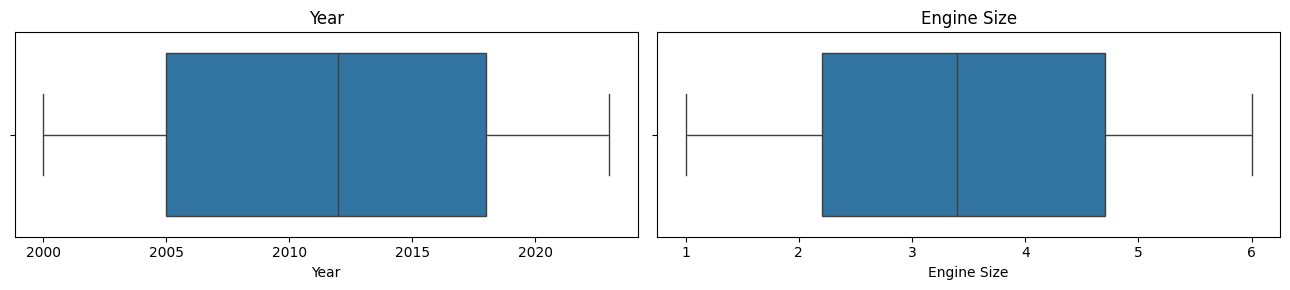

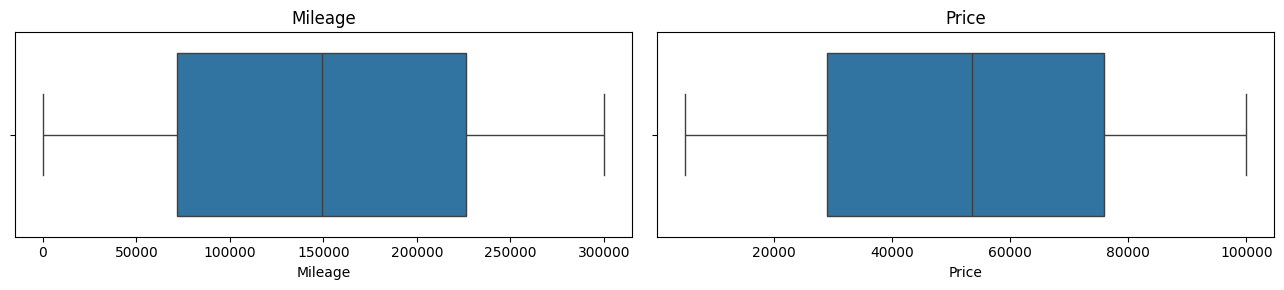

In [189]:
for i in range(0, len(num_cols), 2):
    fig = plt.figure(figsize=(13,3))

    plt.subplot(1,2,1)
    sns.boxplot(x=num_cols[i], data=df)
    plt.title(num_cols[i])

    if i+1 < len(num_cols):
        plt.subplot(1,2,2)
        sns.boxplot(x=num_cols[i+1], data=df)
        plt.title(num_cols[i+1])

    plt.tight_layout()
    plt.show()

In [190]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col} → {len(outliers)} outliers")

Year → 0 outliers
Engine Size → 0 outliers
Mileage → 0 outliers
Price → 0 outliers


In [191]:
df['Brand'].value_counts().sort_values(ascending=False)

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

Text(0, 0.5, 'Frequency')

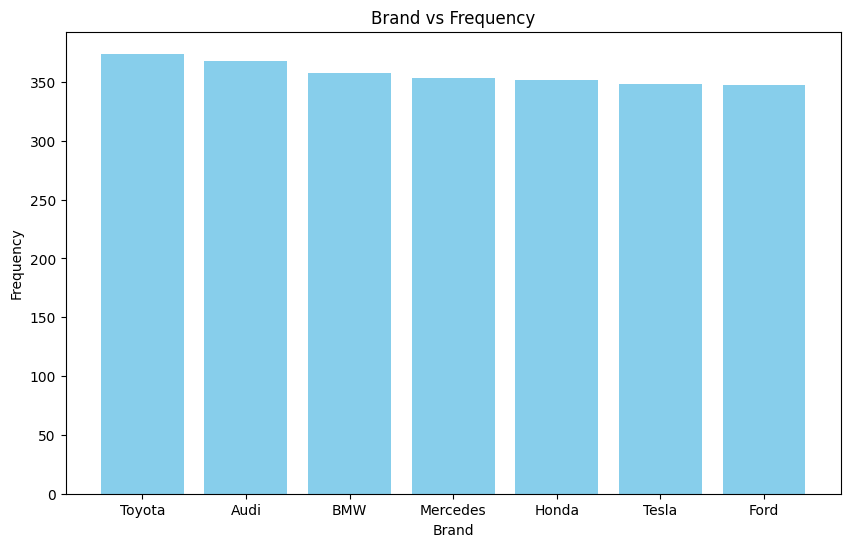

In [192]:
plt.figure(figsize=(10,6))
plt.bar(df['Brand'].value_counts().index, df['Brand'].value_counts().values, color='skyblue')
plt.title('Brand vs Frequency')
plt.xlabel('Brand')
plt.ylabel('Frequency')


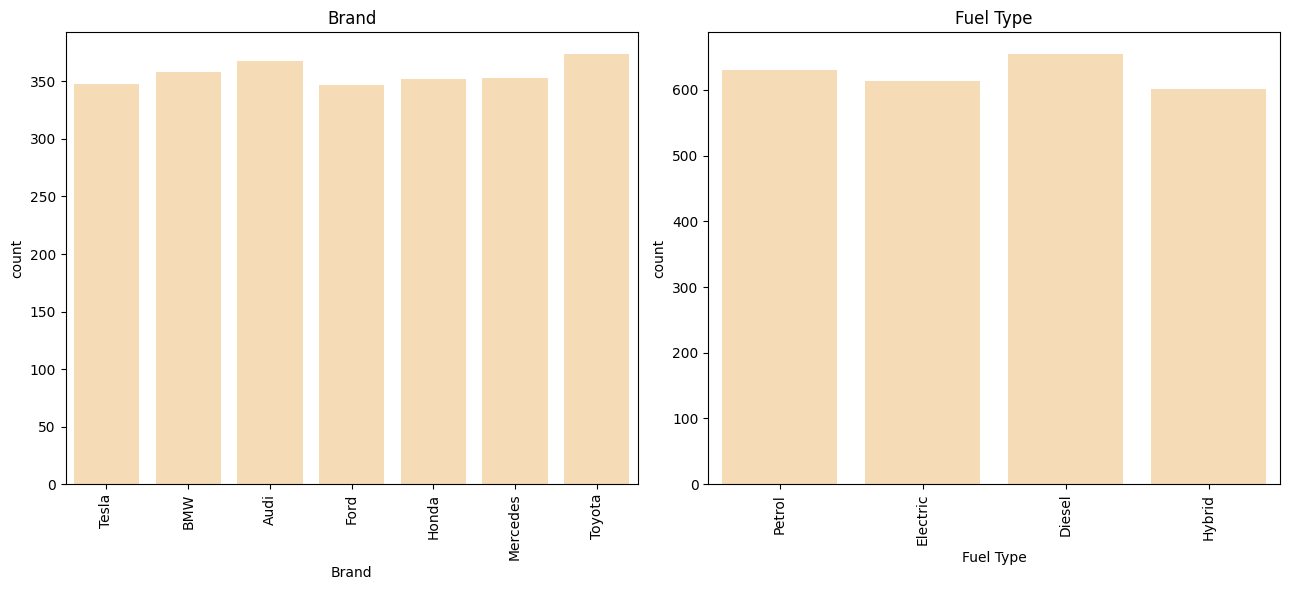

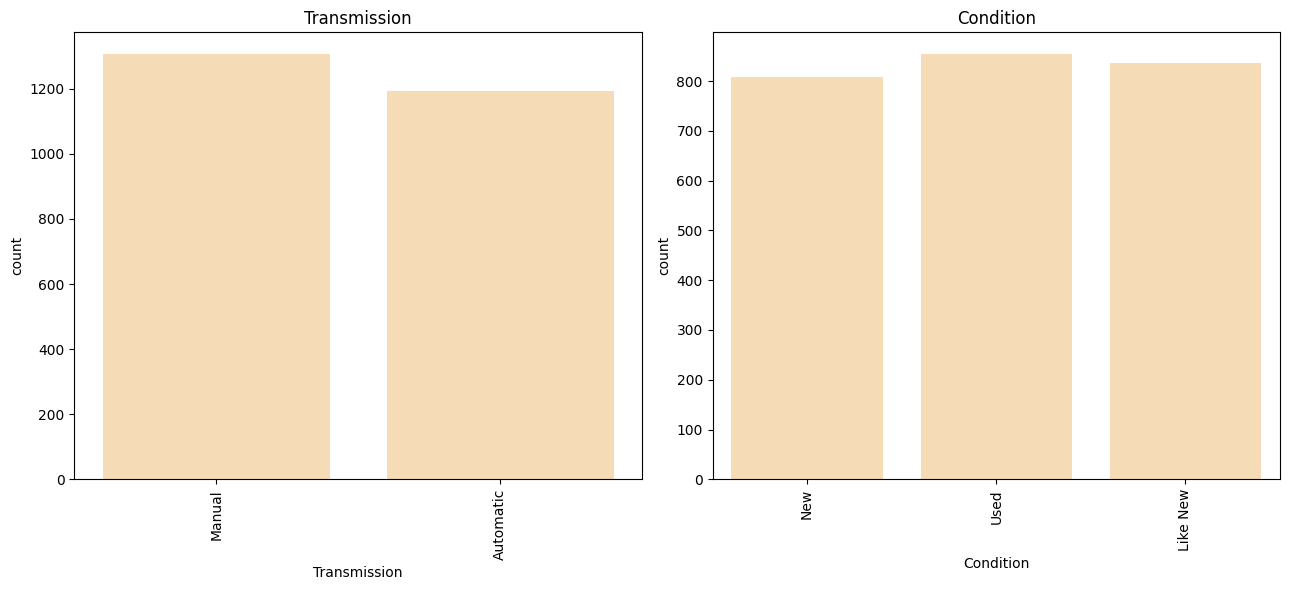

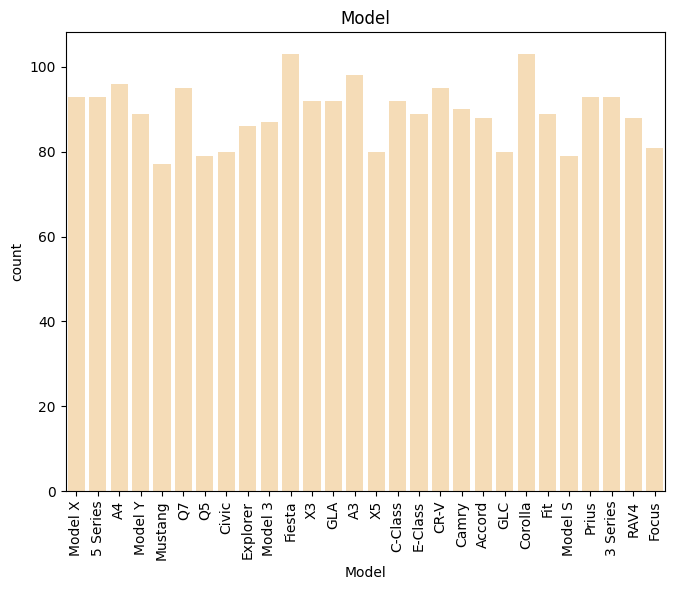

In [193]:
for i in range(0, len(categorical_cols), 2):
    fig = plt.figure(figsize=(13,6))

    plt.subplot(1,2,1)
    sns.countplot(x=categorical_cols[i], data=df, color='navajowhite')
    plt.xticks(rotation=90)
    plt.title(categorical_cols[i])

    if i+1 < len(categorical_cols):
        plt.subplot(1,2,2)
        sns.countplot(x=categorical_cols[i+1], data=df, color='navajowhite')
        plt.xticks(rotation=90)
        plt.title(categorical_cols[i+1])

    plt.tight_layout()
    plt.show()

In [194]:
df["Model"].value_counts()

Model
Fiesta      103
Corolla     103
A3           98
A4           96
Q7           95
CR-V         95
5 Series     93
3 Series     93
Prius        93
Model X      93
C-Class      92
X3           92
GLA          92
Camry        90
E-Class      89
Fit          89
Model Y      89
RAV4         88
Accord       88
Model 3      87
Explorer     86
Focus        81
Civic        80
X5           80
GLC          80
Q5           79
Model S      79
Mustang      77
Name: count, dtype: int64

In [195]:
df['Year'].value_counts()


Year
2020    122
2016    118
2003    118
2022    112
2021    112
2012    111
2007    110
2002    110
2008    109
2014    109
2001    109
2018    106
2019    103
2023    103
2005    103
2011    101
2004    100
2017     97
2010     95
2013     95
2000     93
2009     90
2015     88
2006     86
Name: count, dtype: int64

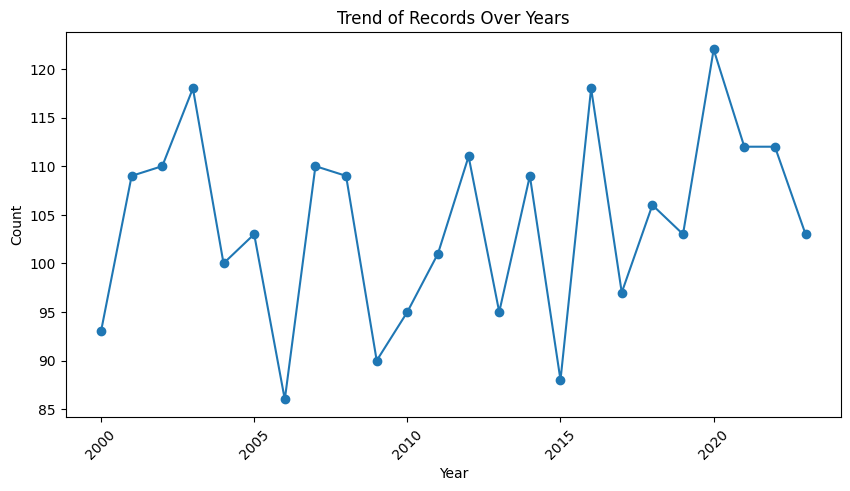

In [196]:
plt.figure(figsize=(10,5))
plt.plot(df['Year'].value_counts().sort_index().index, df['Year'].value_counts().sort_index().values, marker='o')

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trend of Records Over Years")
plt.xticks(rotation=45)
plt.show()

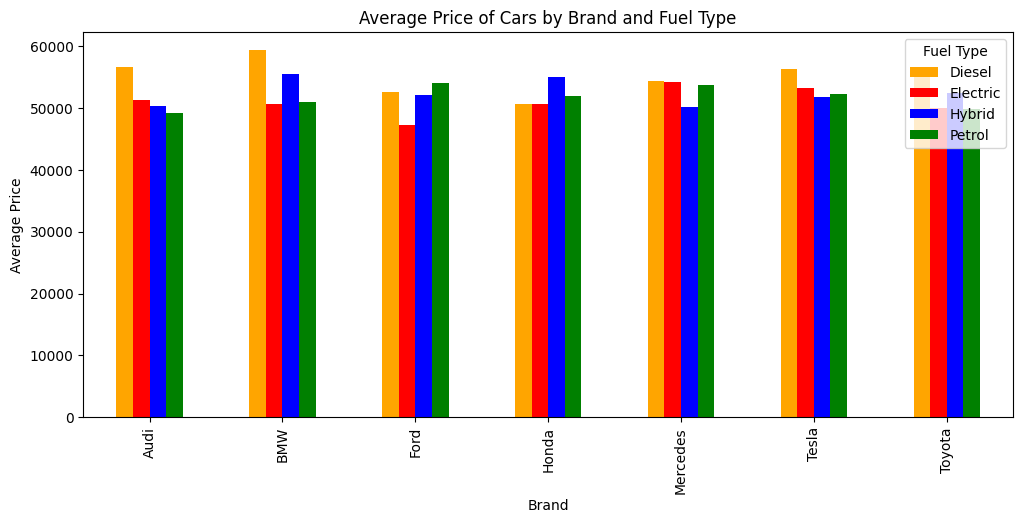

In [197]:
df.groupby(["Fuel Type","Brand"])["Price"].mean().sort_values(ascending=False).reset_index().pivot(index="Brand",columns="Fuel Type",values="Price").plot(kind="bar", figsize=(12, 5), color=["orange","red","blue","green"])
plt.title("Average Price of Cars by Brand and Fuel Type")
plt.ylabel("Average Price")  
plt.xlabel("Brand")  
plt.xticks(rotation=90)
plt.legend(title="Fuel Type")
plt.show()

In [198]:
df.shape

(2500, 9)

In [199]:
df.describe()

,Year,Engine Size,Mileage,Price
count,2500.0000,2500.000000,2500.000000,2500.000000
mean,2011.6268,3.465240,149749.844800,52638.022532
std,6.9917,1.432053,87919.952034,27295.833455
min,2000.0000,1.000000,15.000000,5011.270000
25%,2005.0000,2.200000,71831.500000,28908.485000
50%,2012.0000,3.400000,149085.000000,53485.240000
75%,2018.0000,4.700000,225990.500000,75838.532500
max,2023.0000,6.000000,299967.000000,99982.590000


In [200]:
df_cleaned = df.copy()

In [201]:
df_cleaned['Year'].max()

np.int64(2023)

In [202]:
df_cleaned["Age"] = 2023 - df_cleaned["Year"]
df_cleaned.drop('Year',axis=1,inplace = True)

In [203]:
df_cleaned

,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Age
0,Tesla,2.3,Petrol,Manual,114832,New,26613.92,Model X,7
1,BMW,4.4,Electric,Manual,143190,Used,14679.61,5 Series,5
2,Audi,4.5,Electric,Manual,181601,New,44402.61,A4,10
3,Tesla,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,12
4,Ford,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,14
...,...,...,...,...,...,...,...,...,...
2495,Audi,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5,3
2496,Audi,5.7,Hybrid,Manual,77701,Like New,24710.35,A3,22
2497,Ford,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta,2
2498,Audi,4.5,Diesel,Manual,229164,Like New,46085.67,Q5,21


In [206]:
len(df_cleaned["Brand"].unique())

7